In [1]:
import matplotlib.pyplot as plt
import numpy as np
import parflow as pf
import numpy as np
from glob import glob

import datetime
import os
import re
import shutil
import yaml

# Parflow specific packages
from parflow import Run
from parflow.tools.settings import set_working_directory
from parflow.tools.fs import get_absolute_path, cp, rm, mkdir, exists


In [2]:
tag = datetime.datetime.now().strftime('%Y%m%d')

run_name = "contamination_model"
run_dir  = f'./{tag}'

if os.path.isdir(run_dir):
    shutil.rmtree(run_dir)
mkdir(run_dir)

model = Run(run_name, run_dir)

In [3]:

input_dir = os.path.join(os.getcwd(), f'input')
files = os.listdir(input_dir)

# do not include .ipynb_check files in copying from 'input' folder
for fname in files:
    if '.ipynb_check' not in fname:
        shutil.copy(os.path.join(input_dir,fname), run_dir)

### Establish the Model's Computational Grid and Disretization

In [4]:
# -----------------------------------------------------------------------------
# File input version number
# -----------------------------------------------------------------------------
model.FileVersion = 4

# -----------------------------------------------------------------------------
# Process Topology
# -----------------------------------------------------------------------------

model.Process.Topology.P = 10
model.Process.Topology.Q = 1
model.Process.Topology.R = 1

# -----------------------------------------------------------------------------
# GRID ASPECTS
# -----------------------------------------------------------------------------

l_z = 29.8 # cm
l_x = 51.2 # cm
l_y = 2.54 # cm

# -----------------------------------------------------------------------------
# Computational Grid
# -----------------------------------------------------------------------------
model.ComputationalGrid.Lower.X = 0.0
model.ComputationalGrid.Lower.Y = 0.0
model.ComputationalGrid.Lower.Z = 0.0

model.ComputationalGrid.NX = 100
model.ComputationalGrid.NY = 3
model.ComputationalGrid.NZ = 60 

model.ComputationalGrid.DX = l_x/model.ComputationalGrid.NX 
model.ComputationalGrid.DY = l_y/model.ComputationalGrid.NY
model.ComputationalGrid.DZ = l_z/model.ComputationalGrid.NZ

### Establish the Domain's Geometry

In [5]:
# -----------------------------------------------------------------------------
# Domain
# set the name for your `Domain` and setup the patches for this domain
# -----------------------------------------------------------------------------
model.Domain.GeomName = "domain"


# -----------------------------------------------------------------------------
# The Names of the GeomInputs
# -----------------------------------------------------------------------------
model.GeomInput.Names = (
    "domain_input background_input indicator_input"
)

# -----------------------------------------------------------------------------
# Domain Geometry Input
# -----------------------------------------------------------------------------
model.GeomInput.domain_input.InputType = "Box"
model.GeomInput.domain_input.GeomName = "domain"

# -----------------------------------------------------------------------------
# Domain Geometry
# -----------------------------------------------------------------------------
model.Geom.domain.Lower.X = 0.0
model.Geom.domain.Lower.Y = 0.0
model.Geom.domain.Lower.Z = 0.0

model.Geom.domain.Upper.X = l_x
model.Geom.domain.Upper.Y = l_y
model.Geom.domain.Upper.Z = l_z

In [6]:
model.Geom.domain.Patches = "x_lower x_upper y_lower y_upper z_lower z_upper"

# -----------------------------------------------------------------------------
# Background Geometry Input
# -----------------------------------------------------------------------------
model.GeomInput.background_input.InputType = "Box"
model.GeomInput.background_input.GeomName = "background"

# -----------------------------------------------------------------------------
# Background Geometry
# -----------------------------------------------------------------------------
model.Geom.background.Lower.X = -99999999.0
model.Geom.background.Lower.Y = -99999999.0
model.Geom.background.Lower.Z = -99999999.0

model.Geom.background.Upper.X = 99999999.0
model.Geom.background.Upper.Y = 99999999.0
model.Geom.background.Upper.Z = 99999999.0

In [7]:
# ---------------------------------------------------------
# Topo slopes in x-direction
# ---------------------------------------------------------

model.TopoSlopesX.Type = "Constant"
model.TopoSlopesX.GeomNames = "background"#domain"
model.TopoSlopesX.Geom.background.Value = 0.0

# ---------------------------------------------------------
# Topo slopes in y-direction
# ---------------------------------------------------------

model.TopoSlopesY.Type = "Constant"
model.TopoSlopesY.GeomNames = "background"
model.TopoSlopesY.Geom.background.Value = 0.0

### Model Parameters

In [8]:
# -----------------------------------------------------------------------------
# Indicator Geometry Input
# -----------------------------------------------------------------------------

# will be set once the indi file in created
model.GeomInput.indicator_input.InputType = 'IndicatorField'
model.GeomInput.indicator_input.GeomNames = (
    'inactive aquiclude_1 fractured_bedrock aquiclude_2 confined_artesian_aquifer '+
    'aquitard unconfined_aquifer fine_sand river_channel clay_layer_1 clay_layer_2 '+
    'soil_zone'
)
model.Geom.indicator_input.FileName = f'{run_name}.pfb'

model.GeomInput.aquiclude_1.Value = 1
model.GeomInput.aquiclude_2.Value = 2
model.GeomInput.aquitard.Value = 3
model.GeomInput.clay_layer_1.Value = 4
model.GeomInput.clay_layer_2.Value = 5
model.GeomInput.confined_artesian_aquifer.Value = 6
model.GeomInput.fine_sand.Value = 7
model.GeomInput.fractured_bedrock.Value = 8
model.GeomInput.river_channel.Value = 10
model.GeomInput.soil_zone.Value = 11
model.GeomInput.unconfined_aquifer.Value = 12
model.GeomInput.inactive.Value = 0



In [9]:
## SUBSURFACE PROPERTIES 
# -----------------------------------------------------------------------------
# Perm
# -----------------------------------------------------------------------------
model.Geom.Perm.Names = (
    'inactive aquiclude_1 fractured_bedrock aquiclude_2 confined_artesian_aquifer '+
    'aquitard unconfined_aquifer fine_sand river_channel clay_layer_1 clay_layer_2 '+
    'soil_zone'
)

low_k = 0.0001/600
hi_k = 0.5

model.Geom.inactive.Perm.Type = 'Constant'
model.Geom.inactive.Perm.Value = low_k # 0.0

model.Geom.aquiclude_1.Perm.Type = 'Constant'
model.Geom.aquiclude_1.Perm.Value = low_k

model.Geom.aquiclude_2.Perm.Type = 'Constant'
model.Geom.aquiclude_2.Perm.Value = low_k

model.Geom.aquitard.Perm.Type = 'Constant'
model.Geom.aquitard.Perm.Value = low_k

model.Geom.clay_layer_1.Perm.Type = 'Constant'
model.Geom.clay_layer_1.Perm.Value = low_k

model.Geom.clay_layer_2.Perm.Type = 'Constant'
model.Geom.clay_layer_2.Perm.Value = low_k

model.Geom.confined_artesian_aquifer.Perm.Type = 'Constant'
model.Geom.confined_artesian_aquifer.Perm.Value = hi_k

model.Geom.fine_sand.Perm.Type = 'Constant'
model.Geom.fine_sand.Perm.Value = hi_k

model.Geom.fractured_bedrock.Perm.Type = 'Constant'
model.Geom.fractured_bedrock.Perm.Value = hi_k

model.Geom.river_channel.Perm.Type = 'Constant'
model.Geom.river_channel.Perm.Value = hi_k

model.Geom.soil_zone.Perm.Type = 'Constant'
model.Geom.soil_zone.Perm.Value = hi_k

model.Geom.unconfined_aquifer.Perm.Type = 'Constant'
model.Geom.unconfined_aquifer.Perm.Value = hi_k

# model.Geom.background.Perm.Type = 'Constant'
# model.Geom.background.Perm.Value = hi_k

In [10]:
model.Perm.TensorType = "TensorByGeom"

model.Geom.Perm.TensorByGeom.Names = "background"

model.Geom.background.Perm.TensorValX = 1.0
model.Geom.background.Perm.TensorValY = 1.0
model.Geom.background.Perm.TensorValZ = 1.0

In [11]:
# -----------------------------------------------------------------------------
# Porosity
# -----------------------------------------------------------------------------

model.Geom.Porosity.GeomNames = "background"

model.Geom.background.Porosity.Type = "Constant"
model.Geom.background.Porosity.Value = 0.4 

# ---------------------------------------------------------
# Mannings coefficient
# ---------------------------------------------------------

model.Mannings.Type = "Constant"
model.Mannings.GeomNames = "domain"
model.Mannings.Geom.domain.Value = 2.3e-7

# -----------------------------------------------------------------------------
# Specific Storage
# -----------------------------------------------------------------------------

model.SpecificStorage.Type = "Constant"
model.SpecificStorage.GeomNames = "background"
model.Geom.background.SpecificStorage.Value = 1.0e-5

# -----------------------------------------------------------------------------
# Gravity
# -----------------------------------------------------------------------------

model.Gravity = 1.0

### Model Phases

In [12]:
# -----------------------------------------------------------------------------
# Phases
# -----------------------------------------------------------------------------

model.Phase.Names = "water"

model.Phase.water.Density.Type = "Constant"
model.Phase.water.Density.Value = 1.0

model.Phase.water.Viscosity.Type = "Constant"
model.Phase.water.Viscosity.Value = 1.0

# -----------------------------------------------------------------------------
# Mobility
# -----------------------------------------------------------------------------
model.Phase.water.Mobility.Type = "Constant"
model.Phase.water.Mobility.Value = 1.0

# -----------------------------------------------------------------------------
# Heat Capacity
# -----------------------------------------------------------------------------

model.Phase.water.HeatCapacity.Type = "Constant"
model.Phase.water.HeatCapacity.GeomNames = "background"
model.Phase.water.Geom.background.HeatCapacity.Value = 4000.0

# -----------------------------------------------------------------------------
# Contaminants
# -----------------------------------------------------------------------------
model.Contaminants.Names = "dummy"
model.Contaminants.dummy.Degradation.Value = 0.0

# -----------------------------------------------------------------------------
# Retardation
# -----------------------------------------------------------------------------
model.Geom.Retardation.GeomNames = "background"
model.Geom.background.dummy.Retardation.Type = "Linear"
model.Geom.background.dummy.Retardation.Rate = 0.0

### Model Time Cycle

In [13]:
# -----------------------------------------------------------------------------
# Setup timing info
# -----------------------------------------------------------------------------

model.TimingInfo.BaseUnit = 0.25
model.TimingInfo.StartCount = 0
model.TimingInfo.StartTime = 0.0
model.TimingInfo.StopTime = 5.0
model.TimingInfo.DumpInterval = 0.25

model.TimeStep.Type = "Constant"
model.TimeStep.Value = 1.0

# -----------------------------------------------------------------------------
# Time Cycles
# -----------------------------------------------------------------------------
model.Cycle.Names = "constant"
model.Cycle.constant.Names = "alltime"
model.Cycle.constant.alltime.Length = 1
model.Cycle.constant.Repeat = -1

### Boundary and Initial Conditions 

In [14]:
# -----------------------------------------------------------------------------
# Boundary Conditions: Pressure
# -----------------------------------------------------------------------------
model.BCPressure.PatchNames = "x_lower x_upper y_lower y_upper z_lower z_upper"

model.Patch.x_lower.BCPressure.Type = "DirEquilRefPatch"
model.Patch.x_lower.BCPressure.Cycle = "constant"
model.Patch.x_lower.BCPressure.RefGeom = "domain"
model.Patch.x_lower.BCPressure.RefPatch = "z_lower"
model.Patch.x_lower.BCPressure.alltime.Value = 30*model.ComputationalGrid.DZ

model.Patch.x_upper.BCPressure.Type = "DirEquilRefPatch"
model.Patch.x_upper.BCPressure.Cycle = "constant"
model.Patch.x_upper.BCPressure.RefGeom = "domain"
model.Patch.x_upper.BCPressure.RefPatch = "z_lower"
model.Patch.x_upper.BCPressure.alltime.Value = l_z

model.Patch.y_lower.BCPressure.Type = "FluxConst"
model.Patch.y_lower.BCPressure.Cycle = "constant"
model.Patch.y_lower.BCPressure.alltime.Value = 0.0

model.Patch.y_upper.BCPressure.Type = "FluxConst"
model.Patch.y_upper.BCPressure.Cycle = "constant"
model.Patch.y_upper.BCPressure.alltime.Value = 0.0

model.Patch.z_lower.BCPressure.Type = "FluxConst"
model.Patch.z_lower.BCPressure.Cycle = "constant"
model.Patch.z_lower.BCPressure.alltime.Value = 0.0

model.Patch.z_upper.BCPressure.Type = "FluxConst"
model.Patch.z_upper.BCPressure.Cycle = "constant"
model.Patch.z_upper.BCPressure.alltime.Value = 0.0

# -----------------------------------------------------------------------------
# Phase sources:
# -----------------------------------------------------------------------------
model.PhaseSources.water.Type = "Constant"
model.PhaseSources.water.GeomNames = "background"
model.PhaseSources.water.Geom.background.Value = 0.0

In [15]:
# -----------------------------------------------------------------------------
# INITIAL CONDITIONS:
# -----------------------------------------------------------------------------
model.PhaseConcen.water.dummy.Type = "Constant"
model.PhaseConcen.water.dummy.GeomNames = "background"
model.PhaseConcen.water.dummy.Geom.background.Value = 0.0

### Establish the wells

In [16]:
# -----------------------------------------------------------------------------
# Wells
# -----------------------------------------------------------------------------
model.Wells.Names        = "inj ext"

# INJECTION
model.Wells.inj.InputType = "Vertical"
model.Wells.inj.Action = "Injection"
model.Wells.inj.Cycle = "constant"
model.Wells.inj.Type = "Flux"

model.Wells.inj.X = 46.5
model.Wells.inj.Y = l_y/2
model.Wells.inj.ZUpper = 14.5
model.Wells.inj.ZLower = model.Wells.inj.ZUpper-0.5

model.Wells.inj.Method = "Weighted"
model.Wells.inj.alltime.Flux.water.Value = 250.0
model.Wells.inj.alltime.Saturation.water.Value = 1.0
model.Wells.inj.alltime.Concentration.water.dummy.Value = 100.0

# EXTRACTION 
model.Wells.ext.InputType = "Vertical"
model.Wells.ext.Action = "Extraction"
model.Wells.ext.Cycle = "constant"
model.Wells.ext.Type = "Flux"

model.Wells.ext.X = 16.5
model.Wells.ext.Y = l_y/2 
model.Wells.ext.ZUpper = 11.3 
model.Wells.ext.ZLower = model.Wells.ext.ZUpper-0.5

model.Wells.ext.Method = "Weighted"
model.Wells.ext.alltime.Flux.water.Value = 550.0

### Solver Settings

In [17]:
model.Solver.PrintSubsurfData = True
model.Solver.PrintPressure = True
model.Solver.PrintSaturation = True
model.Solver.PrintMannings = True
model.Solver.PrintConcentration = True
model.Solver.PrintVelocities = True

In [18]:
# -----------------------------------------------------------------------------
# The Solver Impes MaxIter default value changed so to get previous
# results we need to set it back to what it was
# -----------------------------------------------------------------------------
model.Solver = "Impes"
model.Solver.Linear = "PCG"
model.Solver.MaxIter = 100000
model.Solver.AdvectOrder = 1

### Run the model

In [19]:
model.write()
model.write(file_format='yaml')
model.write(file_format='json')
model.dist(f'{run_name}.pfb')
model.run()

: Field _run_file is not part of the expected schema <class 'parflow.tools.core.Run'>

# ==============================================================================
# ParFlow directory
#  - /opt/parflow/
# ParFlow version
#  - 3.13.0
# Working directory
#  - /home/jovyan/Contamination_simple/20260127
# ParFlow database
#  - contamination_model.pfidb
# ==============================================================================


# ==============================================================================
# ParFlow ran successfully
# ==============================================================================



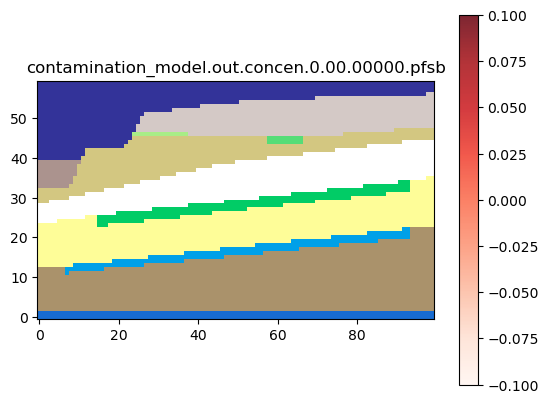

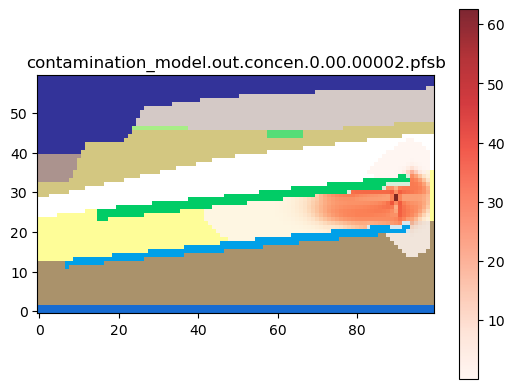

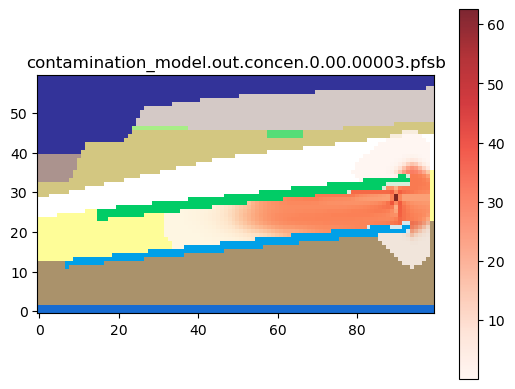

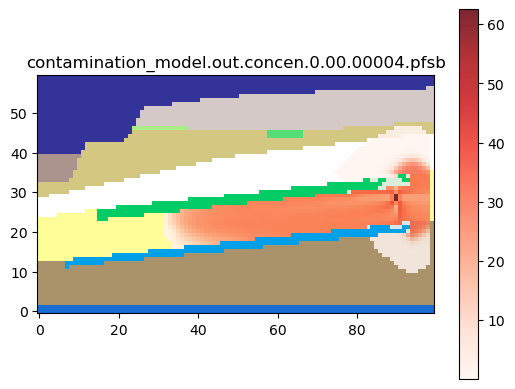

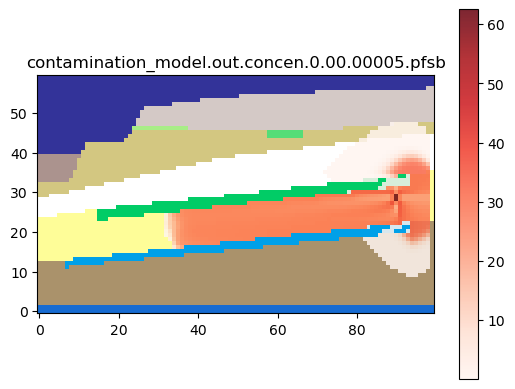

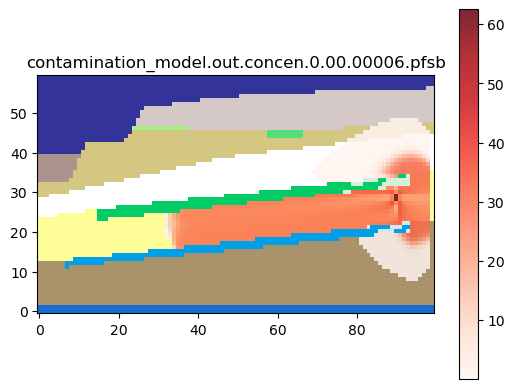

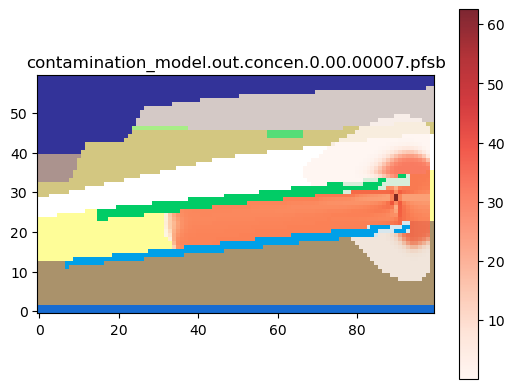

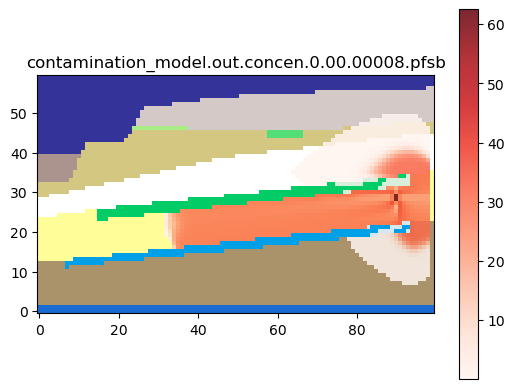

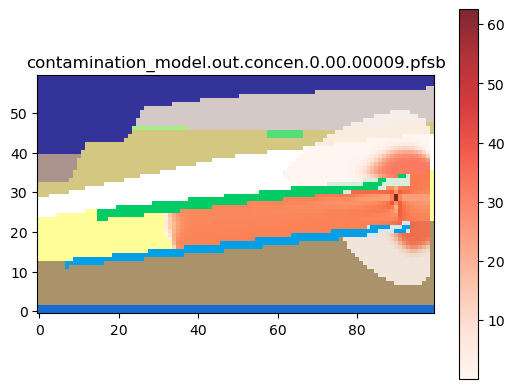

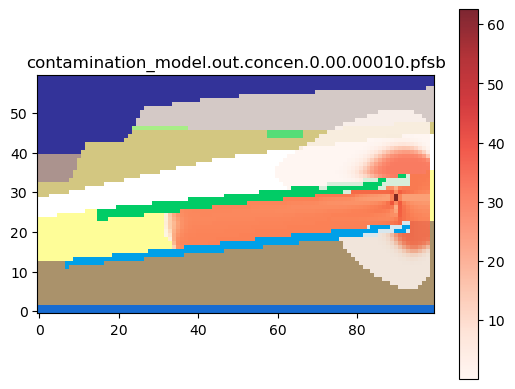

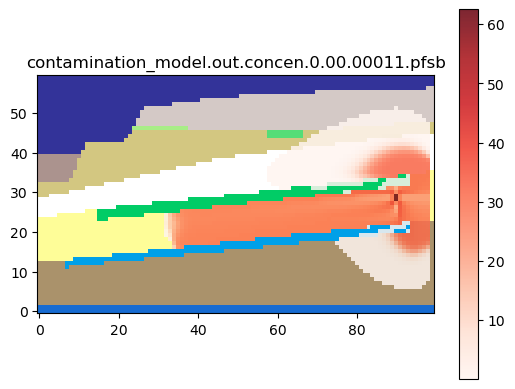

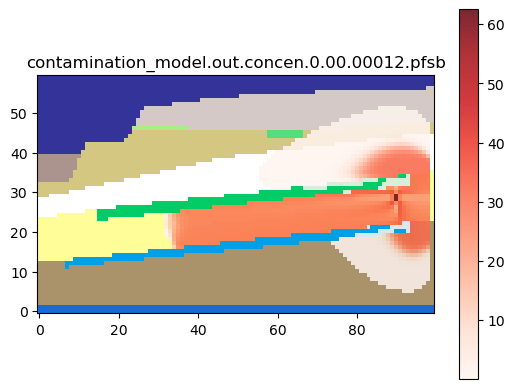

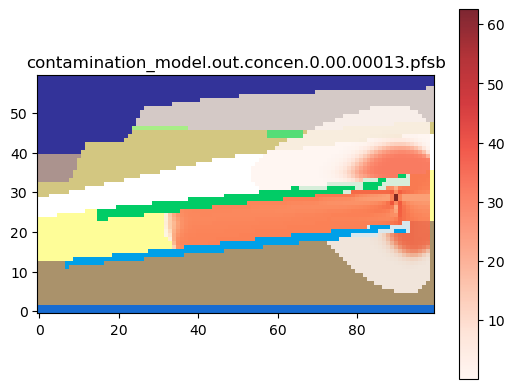

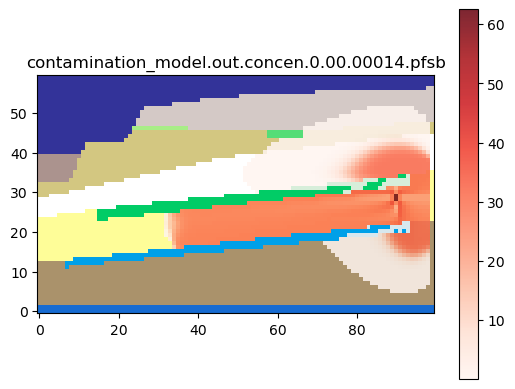

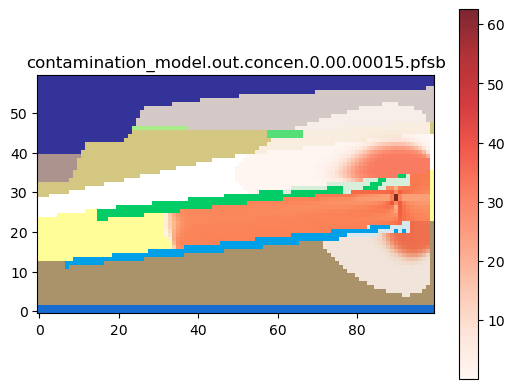

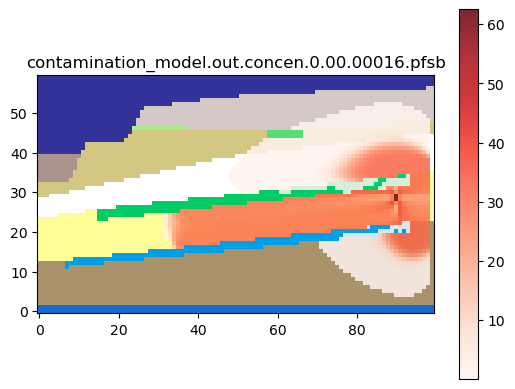

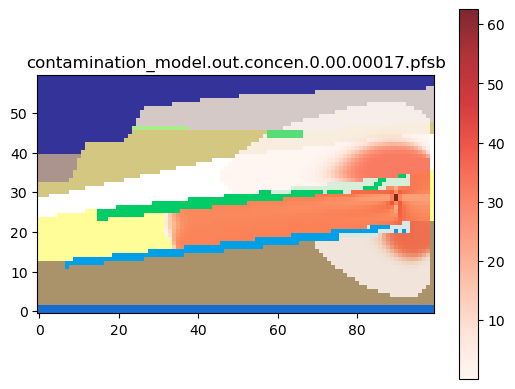

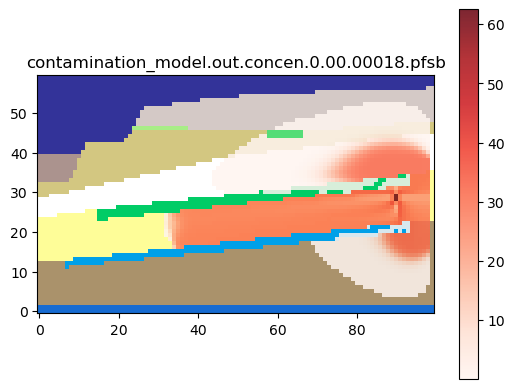

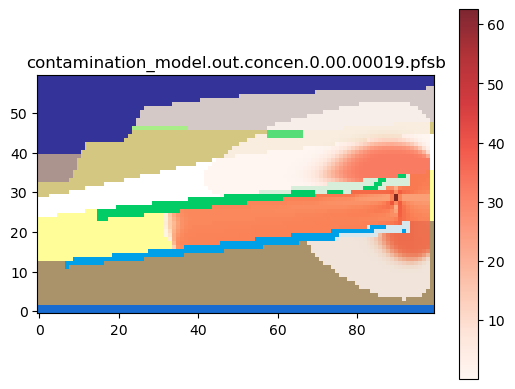

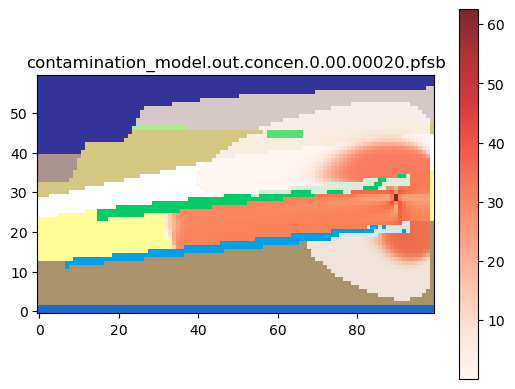

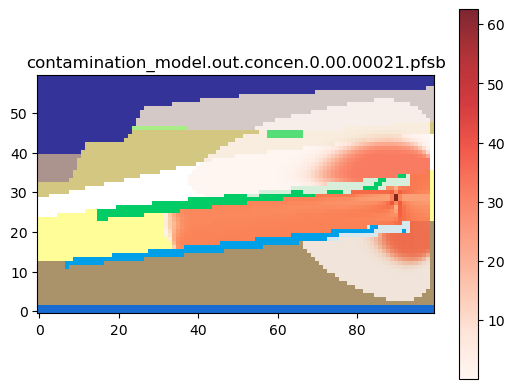

All pertinent figures displayed.


In [20]:
from glob import glob
pf_output_files = glob(f'{run_dir}/{run_name}*out.concen*.pfsb')
pf_output_files.sort()

import parflow.tools.io as pft
import matplotlib.pyplot as plt
import numpy as np

from parflowio.pyParflowio import PFData
model_indicator = PFData('./contamination_model.pfb')
model_indicator.loadHeader()
model_indicator.loadData()
indi = model_indicator.viewDataArray()

for i, f in enumerate(pf_output_files):
    raw = pft.read_pfsb(f)
    plt.figure()
    plt.imshow(indi[:,0,:], cmap='terrain')
    plt.imshow(np.where(raw[:, 1, :]<=0, np.nan, raw[:, 1,:]), cmap='Reds', alpha=0.85)
    plt.gca().invert_yaxis()
    plt.colorbar()
    plt.title(f.split('/')[-1])
    plt.show()
print("All pertinent figures displayed.")

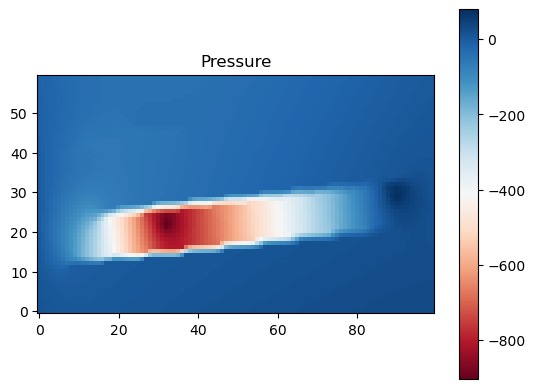

In [21]:
import parflow as pf
pf_output_files = glob(f'{run_dir}/{run_name}*out.press*.pfb')
press = pf.read_pfb_sequence(pf_output_files)

plt.imshow(press[0, :, 0,:], cmap='RdBu')
plt.title('Pressure')
plt.colorbar()
plt.gca().invert_yaxis()

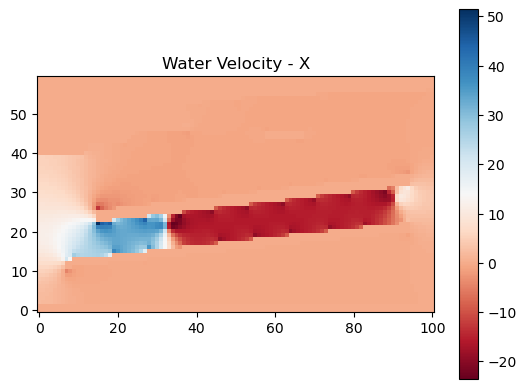

In [22]:
pf_output_files = glob(f'{run_dir}/{run_name}*out.phasex.0.*.pfb')
vel = pf.read_pfb_sequence(pf_output_files)

plt.imshow(vel[0, :,0,:], cmap='RdBu')
plt.title('Water Velocity - X')
plt.colorbar()
plt.gca().invert_yaxis()

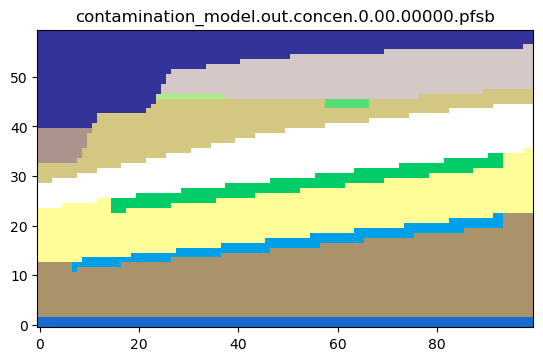

In [23]:
# plotting water table elvation gif
import matplotlib.animation as animation
import matplotlib.patches as patches
import scipy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib import gridspec
from scipy.ndimage import map_coordinates

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import matplotlib.animation as animation
from glob import glob
from matplotlib import colors
from matplotlib.colors import LinearSegmentedColormap

# Base map setup
pf_output_files = glob(f'{run_dir}/{run_name}*out.concen*.pfsb')
pf_output_files.sort()

import parflow.tools.io as pft
import matplotlib.pyplot as plt
import numpy as np
from parflowio.pyParflowio import PFData

#repeated item load concentration
fig, ax = plt.subplots()

colors = [(30/255, 110/255, 105/255, 0.0), (30/255, 110/255, 105/255, 1.0)]
atb_cmap = LinearSegmentedColormap.from_list('alpha_to_blue', colors, N=100)

def redraw_figure(i):
    raw = pft.read_pfsb(pf_output_files[i])
    
    ax.imshow(indi[:,0,:], cmap='terrain') 
    cb = ax.imshow(np.where(raw[:, 1, :]<=0, np.nan, raw[:, 1,:]), cmap=atb_cmap, alpha=0.85)
    ax.invert_yaxis()
    # plt.colorbar(cb)
    ax.set_title(pf_output_files[i].split('/')[-1])
    return fig


# Build and save animation
anim = animation.FuncAnimation(fig=fig,
                               func=redraw_figure,
                               frames=len(pf_output_files),
                               interval=1,
                               repeat=True)

# # Save the animation as a GIF
anim.save(f'{run_name}_concentration.gif', fps=3)